# **LinkedIn Data Analyst jobs listings**

The purpose of this project is to make salary preditction for linkedln Jobs.

Data transformation and machine learning will be used to create a model that will predict a salary when given job title, company, industry, function , employement type and Seniority level ...

The data for this model has many  missing values. The raw data consists of a training dataset with the features listed above and their corresponding salaries. Eighty percent of the dataset are for training model and twenty percent of the dataset are for testing models.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [14]:
#from google.colab import drive
#drive.mount('/content/drive')

# **Gathering Data**

In [15]:
#import os
#path = 'drive/MyDrive/'
#my_files  = ['linkedin-jobs-canada.csv','linkedin-jobs-africa.csv','linkedin-jobs-usa.csv']
#files = os.listdir(path)
#print([f for f in files if f in my_files])


In [16]:
list1='Datasets/linkedin-jobs-canada.csv'
list2='Datasets/linkedin-jobs-africa.csv'
list3='Datasets/linkedin-jobs-usa.csv'
region=['canada','africa','usa']
df1 = pd.read_csv(list1)
df1['region']=pd.Series([region[0] for x in range(len(df1.index))])
df2 = pd.read_csv(list2)
df2['region']=pd.Series([region[1] for x in range(len(df2.index))])
df3 = pd.read_csv(list3)
df3['region']=pd.Series([region[2] for x in range(len(df3.index))])


#display(df2)

In [17]:
#dataset=pd.concat(
#  map(pd.read_csv,[list1,list2,list3]))
dataset=pd.concat([df1,df2,df3], ignore_index=True)
#dataset.head()
display(dataset)


,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
0,Data Analyst,Axonify,Axonify is an intelligent workforce enablement...,onsite,NaN,"Waterloo, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-10-24,https://ca.linkedin.com/jobs/view/data-analyst...,canada
1,Data Analyst,B3 Systems,The ideal candidate will use their passion for...,onsite,NaN,"Toronto, Ontario, Canada",[{'Employment type': 'Full-time'}],2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
2,Data Analyst,Wood Mackenzie,Company DescriptionWood Mackenzie is the globa...,onsite,NaN,"Calgary, Alberta, Canada","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
3,Data Analyst,LOFT Community Services,1 Part Time Permanent PositionDATE: November 1...,onsite,NaN,"Toronto, Ontario, Canada",[{'Employment type': 'Part-time'}],2022-11-17,https://ca.linkedin.com/jobs/view/data-analyst...,canada
4,Data Analyst,NAM Info Inc,"Position: Data AnalystWork Locations: Toronto,...",onsite,NaN,"Toronto, Ontario, Canada","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-08,https://ca.linkedin.com/jobs/view/data-analyst...,canada
...,...,...,...,...,...,...,...,...,...,...
8485,Junior Data Analyst,Iris Software Inc.,"Iris's client, one of the world's largest fina...",hybrid,NaN,"Texas, United States","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-21,https://www.linkedin.com/jobs/view/junior-data...,usa
8486,Data Analyst (SQL),Marwood Group,The Marwood Group (Marwood) is a leading healt...,hybrid,"$75,000.00\r\n -\r\n $95...",New York City Metropolitan Area,"[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-26,https://www.linkedin.com/jobs/view/data-analys...,usa
8487,Data Analyst,SmartSense by Digi,"Join a high-performing, tight-knit team at a f...",hybrid,NaN,"Mishawaka, IN","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...,usa
8488,Data Analyst,Synergy Search,Nashville (Berry Hill) based company looking t...,hybrid,"$85,000.00\r\n -\r\n $95...",Nashville Metropolitan Area,"[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-14,https://www.linkedin.com/jobs/view/data-analys...,usa


# **Data Cleaning and Preparation**





In [18]:
from sklearn.impute import SimpleImputer
dataset1=dataset.copy()
#imputer = SimpleImputer(missing_values=np.nan,strategy='most_frequent')
#dataset1['salary']=dataset1['salary'].fillna(dataset1['salary'].mode()[0])
#new_emp = imputer.fit_transform(dataset)
#df = pd.DataFrame(new_emp,columns=dataset.columns)
#dataset1.groupby(['title'])['salary'].apply(pd.Series.mode)
#dataset1
#df

In [19]:
dataset1.loc[dataset1['title'] == 'Junior Data Analyst', 'salary'].value_counts()

$30.00\r\n            -\r\n            $33.00    36
$22.00\r\n            -\r\n            $24.00    35
Name: salary, dtype: int64

In [20]:
dataset1.loc[dataset1['title'] == 'Data Analyst - Recent Graduate', 'salary'].value_counts()

Series([], Name: salary, dtype: int64)

In [21]:
groups = dataset1.groupby('title') 
#groups['title'].value_counts()
# where all the rows within a group is NaN
all_na = groups['salary'].transform(lambda x: x.isna().all())
all_na.value_counts()

# fill global mode
dataset1.loc[all_na, 'salary'] = dataset1['salary'].mode()[0]
dataset1.loc[all_na, 'salary']
# fill with local mode
mode_by_group = groups['salary'].transform(lambda x: x.mode()[0])
dataset1['salary'] = dataset1['salary'].fillna(mode_by_group)
dataset1

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
0,Data Analyst,Axonify,Axonify is an intelligent workforce enablement...,onsite,$50.00\r\n -\r\n $60.00,"Waterloo, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-10-24,https://ca.linkedin.com/jobs/view/data-analyst...,canada
1,Data Analyst,B3 Systems,The ideal candidate will use their passion for...,onsite,$50.00\r\n -\r\n $60.00,"Toronto, Ontario, Canada",[{'Employment type': 'Full-time'}],2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
2,Data Analyst,Wood Mackenzie,Company DescriptionWood Mackenzie is the globa...,onsite,$50.00\r\n -\r\n $60.00,"Calgary, Alberta, Canada","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
3,Data Analyst,LOFT Community Services,1 Part Time Permanent PositionDATE: November 1...,onsite,$50.00\r\n -\r\n $60.00,"Toronto, Ontario, Canada",[{'Employment type': 'Part-time'}],2022-11-17,https://ca.linkedin.com/jobs/view/data-analyst...,canada
4,Data Analyst,NAM Info Inc,"Position: Data AnalystWork Locations: Toronto,...",onsite,$50.00\r\n -\r\n $60.00,"Toronto, Ontario, Canada","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-08,https://ca.linkedin.com/jobs/view/data-analyst...,canada
...,...,...,...,...,...,...,...,...,...,...
8485,Junior Data Analyst,Iris Software Inc.,"Iris's client, one of the world's largest fina...",hybrid,$30.00\r\n -\r\n $33.00,"Texas, United States","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-21,https://www.linkedin.com/jobs/view/junior-data...,usa
8486,Data Analyst (SQL),Marwood Group,The Marwood Group (Marwood) is a leading healt...,hybrid,"$75,000.00\r\n -\r\n $95...",New York City Metropolitan Area,"[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-26,https://www.linkedin.com/jobs/view/data-analys...,usa
8487,Data Analyst,SmartSense by Digi,"Join a high-performing, tight-knit team at a f...",hybrid,$50.00\r\n -\r\n $60.00,"Mishawaka, IN","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...,usa
8488,Data Analyst,Synergy Search,Nashville (Berry Hill) based company looking t...,hybrid,"$85,000.00\r\n -\r\n $95...",Nashville Metropolitan Area,"[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-14,https://www.linkedin.com/jobs/view/data-analys...,usa


In [22]:
dataset1.loc[dataset1['title'] == 'Junior Data Analyst', 'salary'].value_counts()

$30.00\r\n            -\r\n            $33.00    257
$22.00\r\n            -\r\n            $24.00     35
Name: salary, dtype: int64

In [23]:
dataset1.loc[dataset1['title'] == 'Data Analyst - Recent Graduate', 'salary'].value_counts()

$50.00\r\n            -\r\n            $60.00    183
Name: salary, dtype: int64

In [24]:
dataset1.loc[dataset1['title'] == 'Data Analyst', 'salary'].value_counts()

$50.00\r\n            -\r\n            $60.00              3823
$100,000.00\r\n            -\r\n            $120,000.00      50
$85,000.00\r\n            -\r\n            $100,000.00       38
$60.00\r\n            -\r\n            $60.00                37
$125,000.00\r\n            -\r\n            $155,000.00      37
$120,000.00\r\n            -\r\n            $130,000.00      36
$30.00\r\n            -\r\n            $30.00                36
$73,036.00\r\n            -\r\n            $105,901.00       35
$135,000.00\r\n            -\r\n            $140,000.00      34
$70,000.00\r\n            -\r\n            $80,000.00        34
$60,000.00\r\n            -\r\n            $90,000.00        34
$40.00\r\n            -\r\n            $50.00                34
$120,000.00\r\n            -\r\n            $135,000.00      34
$80,000.00\r\n            -\r\n            $110,000.00       34
$90,000.00\r\n            -\r\n            $120,000.00       30
$38.00\r\n            -\r\n            $

In [25]:
dataset1['title'].value_counts()

Data Analyst                            4464
Junior Data Analyst                      292
Senior Data Analyst                      208
Remote Data Analyst Jobs                 195
Data Analyst - Recent Graduate           183
                                        ... 
Senior Data Governance Analyst             1
Business Intelligence Analyst (FP&A)       1
Campaign/Data Analyst                      1
Operational Data Analyst                   1
Junior Data Analyst-Entry Level            1
Name: title, Length: 192, dtype: int64

In [26]:
dataset1.describe()
#print(len(dataset1))
#dataset = dataset.dropna(subset=['salary'])

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
count,8490,8490,8490,8490,8490,8490,8490,8490,8490,8490
unique,192,396,480,3,48,189,296,55,8490,3
top,Data Analyst,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,$50.00\r\n -\r\n $60.00,"Toronto, Ontario, Canada","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-22,https://ca.linkedin.com/jobs/view/data-analyst...,africa
freq,4464,499,309,2897,7221,981,489,796,1,2872


In [27]:
import re

def remove_dollar(str1):
  str2 = ''
  for s in str1:
    if s != '$':
      str2+=s
  return str2


def clean_salary_us(string_salary):
  numbers = re.split('-', string_salary)
  numbers = [remove_dollar(n).strip() for n in numbers]
  numbers = [re.sub(',', '', n) for n in numbers]
  new_numbers = []
  for n in numbers:
    if re.match('CA', n):
      new_numbers.append(n[2:]) 
    else:
      new_numbers.append(n)
  numbers = new_numbers
  numbers = [float(n) for n in numbers]
  salaries = [np.mean(numbers)]
  if salaries[0]<1000:
    salaries[0]=salaries[0]*1000
  return salaries[0]


dataset1['salary'] = [clean_salary_us(s) for s in dataset1['salary']]

In [28]:
dataset1.head()

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
0,Data Analyst,Axonify,Axonify is an intelligent workforce enablement...,onsite,55000.0,"Waterloo, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-10-24,https://ca.linkedin.com/jobs/view/data-analyst...,canada
1,Data Analyst,B3 Systems,The ideal candidate will use their passion for...,onsite,55000.0,"Toronto, Ontario, Canada",[{'Employment type': 'Full-time'}],2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
2,Data Analyst,Wood Mackenzie,Company DescriptionWood Mackenzie is the globa...,onsite,55000.0,"Calgary, Alberta, Canada","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
3,Data Analyst,LOFT Community Services,1 Part Time Permanent PositionDATE: November 1...,onsite,55000.0,"Toronto, Ontario, Canada",[{'Employment type': 'Part-time'}],2022-11-17,https://ca.linkedin.com/jobs/view/data-analyst...,canada
4,Data Analyst,NAM Info Inc,"Position: Data AnalystWork Locations: Toronto,...",onsite,55000.0,"Toronto, Ontario, Canada","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-08,https://ca.linkedin.com/jobs/view/data-analyst...,canada


In [29]:
#convert to dollar
import math
dataset1.loc[dataset1['region'] == 'africa', 'salary']=(dataset1.loc[dataset1['region'] == 'africa', 'salary']/3).astype(int)
dataset1.loc[dataset1['region'] == 'canada', 'salary']=(dataset1.loc[dataset1['region'] == 'canada', 'salary']/1.34).astype(int)
dataset1.head()

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
0,Data Analyst,Axonify,Axonify is an intelligent workforce enablement...,onsite,41044.0,"Waterloo, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-10-24,https://ca.linkedin.com/jobs/view/data-analyst...,canada
1,Data Analyst,B3 Systems,The ideal candidate will use their passion for...,onsite,41044.0,"Toronto, Ontario, Canada",[{'Employment type': 'Full-time'}],2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
2,Data Analyst,Wood Mackenzie,Company DescriptionWood Mackenzie is the globa...,onsite,41044.0,"Calgary, Alberta, Canada","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada
3,Data Analyst,LOFT Community Services,1 Part Time Permanent PositionDATE: November 1...,onsite,41044.0,"Toronto, Ontario, Canada",[{'Employment type': 'Part-time'}],2022-11-17,https://ca.linkedin.com/jobs/view/data-analyst...,canada
4,Data Analyst,NAM Info Inc,"Position: Data AnalystWork Locations: Toronto,...",onsite,41044.0,"Toronto, Ontario, Canada","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-08,https://ca.linkedin.com/jobs/view/data-analyst...,canada


In [30]:
dataset1.tail()

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region
8485,Junior Data Analyst,Iris Software Inc.,"Iris's client, one of the world's largest fina...",hybrid,31500.0,"Texas, United States","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-21,https://www.linkedin.com/jobs/view/junior-data...,usa
8486,Data Analyst (SQL),Marwood Group,The Marwood Group (Marwood) is a leading healt...,hybrid,85000.0,New York City Metropolitan Area,"[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-26,https://www.linkedin.com/jobs/view/data-analys...,usa
8487,Data Analyst,SmartSense by Digi,"Join a high-performing, tight-knit team at a f...",hybrid,55000.0,"Mishawaka, IN","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...,usa
8488,Data Analyst,Synergy Search,Nashville (Berry Hill) based company looking t...,hybrid,90000.0,Nashville Metropolitan Area,"[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-14,https://www.linkedin.com/jobs/view/data-analys...,usa
8489,Data Analyst,Insight Global,Overview - Minimum 5 years in a quantitative d...,hybrid,140000.0,"Burbank, CA","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-14,https://www.linkedin.com/jobs/view/data-analys...,usa


In [31]:
dataset1['region'].value_counts()

africa    2872
usa       2845
canada    2773
Name: region, dtype: int64

In [32]:
from pprint import pprint
import ast

dataset1['index_2'] = dataset1.index 
#dataset.head(5)
labes = []
criteria = list(dataset1['criteria'])
clean_criteria = []
for c,i in zip(dataset1['criteria'], dataset1['index_2']): 
  #print(c[1:-1])
  j_s = ast.literal_eval(c)
  if j_s:
    try:
      clean_criteria.append({'index_2': i, 'Industries':j_s[3]['Industries'], 'Job function':j_s[2]['Job function'],
                             'Employment type':j_s[1]['Employment type'], 'Seniority level':j_s[0]['Seniority level']})
    
    except Exception as e:
      clean_criteria.append({'index_2': i})
    for j in j_s:
      for k in list((j.keys())):
        labes.append(k)

#pprint(clean_criteria[:5])
clean_criteria_df = pd.DataFrame(clean_criteria)
#clean_criteria_df.head(5)

final_df = dataset1.set_index('index_2').join(clean_criteria_df.set_index('index_2'))
#final_df.drop_duplicates(subset=['link'])
#dataset1.merge(clean_criteria_df, left_on='index_2', right_on='index_2')
#dataset1.drop_duplicates()
#final_df

In [33]:
final_df = final_df.dropna()
final_df=final_df.drop_duplicates(subset=['link'])
#final_df=pd.concat([final_df],ignore_index=True)
final_df

,title,company,description,onsite_remote,salary,location,criteria,posted_date,link,region,Industries,Job function,Employment type,Seniority level
index_2,,,,,,,,,,,,,,
0,Data Analyst,Axonify,Axonify is an intelligent workforce enablement...,onsite,41044.0,"Waterloo, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-10-24,https://ca.linkedin.com/jobs/view/data-analyst...,canada,Software Development,Information Technology,Full-time,Entry level
2,Data Analyst,Wood Mackenzie,Company DescriptionWood Mackenzie is the globa...,onsite,41044.0,"Calgary, Alberta, Canada","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-18,https://ca.linkedin.com/jobs/view/data-analyst...,canada,Information Services,Analyst,Full-time,Associate
4,Data Analyst,NAM Info Inc,"Position: Data AnalystWork Locations: Toronto,...",onsite,41044.0,"Toronto, Ontario, Canada","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-11-08,https://ca.linkedin.com/jobs/view/data-analyst...,canada,Staffing and Recruiting,Information Technology,Contract,Mid-Senior level
5,Data Analyst,Citi,Job Id: 22544507This role is for a Data Analys...,onsite,41044.0,"Mississauga, Ontario, Canada","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-15,https://ca.linkedin.com/jobs/view/data-analyst...,canada,"Banking, Financial Services, and Investment Ba...",Information Technology,Full-time,Not Applicable
6,Data Analyst,King's College London,Job DescriptionKing’s Technology Evaluation Ce...,onsite,41044.0,"St Thomas, Ontario, Canada","[{'Seniority level': 'Entry level'}, {'Employm...",2022-11-02,https://ca.linkedin.com/jobs/view/data-analyst...,canada,Research Services,Information Technology,Full-time,Entry level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8485,Junior Data Analyst,Iris Software Inc.,"Iris's client, one of the world's largest fina...",hybrid,31500.0,"Texas, United States","[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-21,https://www.linkedin.com/jobs/view/junior-data...,usa,IT Services and IT Consulting,Information Technology,Contract,Mid-Senior level
8486,Data Analyst (SQL),Marwood Group,The Marwood Group (Marwood) is a leading healt...,hybrid,85000.0,New York City Metropolitan Area,"[{'Seniority level': 'Mid-Senior level'}, {'Em...",2022-10-26,https://www.linkedin.com/jobs/view/data-analys...,usa,Financial Services,"Consulting, General Business, and Strategy/Pla...",Full-time,Mid-Senior level
8487,Data Analyst,SmartSense by Digi,"Join a high-performing, tight-knit team at a f...",hybrid,55000.0,"Mishawaka, IN","[{'Seniority level': 'Associate'}, {'Employmen...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...,usa,"IT Services and IT Consulting, Software Develo...",Engineering,Full-time,Associate


In [34]:
df=final_df.iloc[:,[0,1,3,10,11,12,13,9,4]]
#df=pd.concat([df],ignore_index=True)
df=df.reset_index(drop = True)
df

,title,company,onsite_remote,Industries,Job function,Employment type,Seniority level,region,salary
0,Data Analyst,Axonify,onsite,Software Development,Information Technology,Full-time,Entry level,canada,41044.0
1,Data Analyst,Wood Mackenzie,onsite,Information Services,Analyst,Full-time,Associate,canada,41044.0
2,Data Analyst,NAM Info Inc,onsite,Staffing and Recruiting,Information Technology,Contract,Mid-Senior level,canada,41044.0
3,Data Analyst,Citi,onsite,"Banking, Financial Services, and Investment Ba...",Information Technology,Full-time,Not Applicable,canada,41044.0
4,Data Analyst,King's College London,onsite,Research Services,Information Technology,Full-time,Entry level,canada,41044.0
...,...,...,...,...,...,...,...,...,...
7626,Junior Data Analyst,Iris Software Inc.,hybrid,IT Services and IT Consulting,Information Technology,Contract,Mid-Senior level,usa,31500.0
7627,Data Analyst (SQL),Marwood Group,hybrid,Financial Services,"Consulting, General Business, and Strategy/Pla...",Full-time,Mid-Senior level,usa,85000.0
7628,Data Analyst,SmartSense by Digi,hybrid,"IT Services and IT Consulting, Software Develo...",Engineering,Full-time,Associate,usa,55000.0
7629,Data Analyst,Synergy Search,hybrid,Entertainment Providers,Analyst and Finance,Full-time,Not Applicable,usa,90000.0


# **Exploratory Data Analysis**

In [35]:
df['salary'].describe()

count      7631.000000
mean      41150.570502
std       22410.090934
min        5900.000000
25%       18333.000000
50%       41044.000000
75%       55000.000000
max      140000.000000
Name: salary, dtype: float64

In [36]:
df.groupby(['region'])['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
africa,2438.0,18291.998769,4045.908943,10500.0,18333.0,18333.0,18333.0,46666.0
canada,2541.0,42776.787879,9122.247618,31716.0,41044.0,41044.0,41044.0,104477.0
usa,2652.0,60606.445136,22111.693810,5900.0,55000.0,55000.0,55000.0,140000.0


<AxesSubplot: >

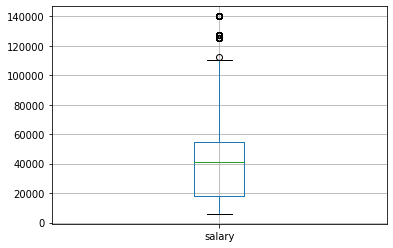

In [37]:
df.boxplot()

In [38]:
company=df.groupby(['company'])['title'].count()
company.sort_values(ascending=False).head(10)

company
PayPal              489
Turing.com          200
Crossover           155
Progressive Edge    143
SSENSE              132
Experian            112
Synechron           110
Insight Global      105
Diverse Lynx         98
Citi                 75
Name: title, dtype: int64

In [39]:
company=df.groupby(['company','region'])['title'].count()
company.sort_values(ascending=False).head(10)

company           region
PayPal            usa       489
Turing.com        africa    200
Progressive Edge  africa    143
SSENSE            canada    132
Crossover         africa    113
Experian          africa    112
Synechron         canada    110
Insight Global    usa        96
Diverse Lynx      canada     88
Citi              canada     75
Name: title, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


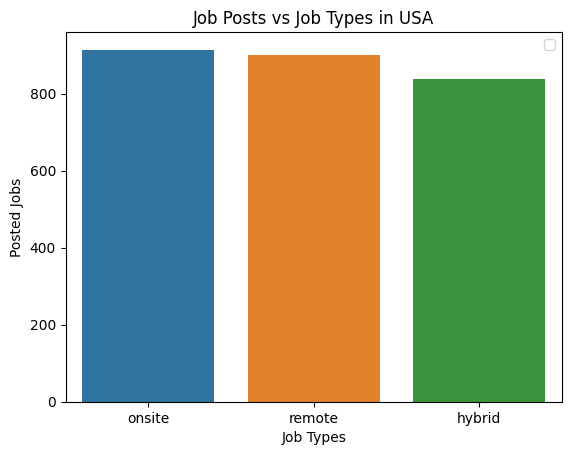

In [40]:
sns.countplot(df[df['region']=='usa'].onsite_remote)
# Add labels and a title
plt.xlabel('Job Types')
plt.ylabel('Posted Jobs')
plt.title('Job Posts vs Job Types in USA')
# Show the legend
plt.legend()

# Display the bar chart
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


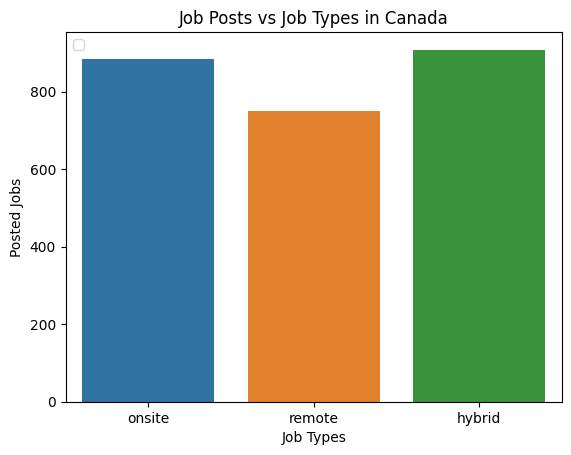

In [41]:
sns.countplot(df[df['region']=='canada'].onsite_remote)
# Add labels and a title
plt.xlabel('Job Types')
plt.ylabel('Posted Jobs')
plt.title('Job Posts vs Job Types in Canada')
# Show the legend
plt.legend()

# Display the bar chart
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


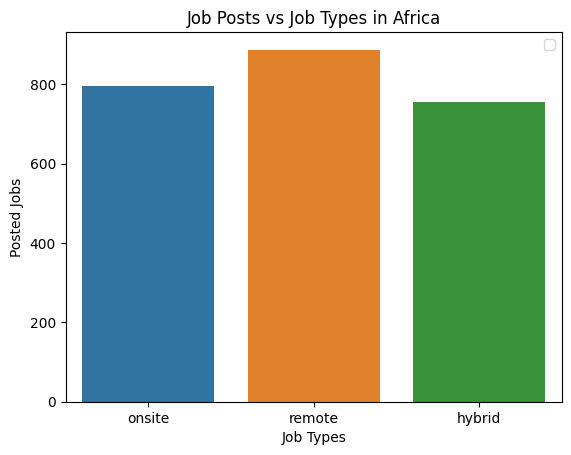

In [42]:
sns.countplot(df[df['region']=='africa'].onsite_remote)
# Add labels and a title
plt.xlabel('Job Types')
plt.ylabel('Posted Jobs')
plt.title('Job Posts vs Job Types in Africa')
# Show the legend
plt.legend()

# Display the bar chart
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


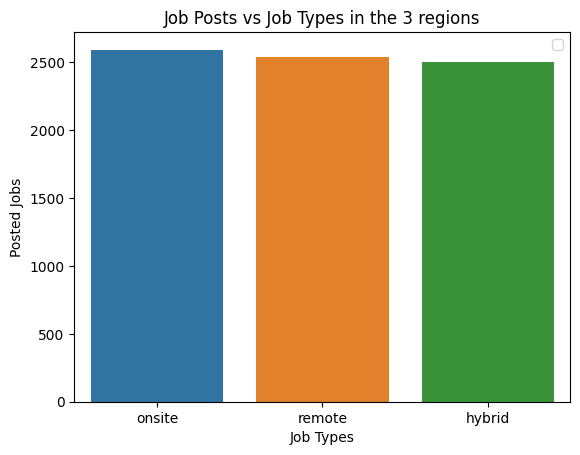

In [43]:
sns.countplot(df.onsite_remote)
# Add labels and a title
plt.xlabel('Job Types')
plt.ylabel('Posted Jobs')
plt.title('Job Posts vs Job Types in the 3 regions')
# Show the legend
plt.legend()

# Display the bar chart
plt.show()

# **Data Modeling**

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7631 entries, 0 to 7630
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            7631 non-null   object 
 1   company          7631 non-null   object 
 2   onsite_remote    7631 non-null   object 
 3   Industries       7631 non-null   object 
 4   Job function     7631 non-null   object 
 5   Employment type  7631 non-null   object 
 6   Seniority level  7631 non-null   object 
 7   region           7631 non-null   object 
 8   salary           7631 non-null   float64
dtypes: float64(1), object(8)
memory usage: 536.7+ KB


In [45]:
df.dtypes

title               object
company             object
onsite_remote       object
Industries          object
Job function        object
Employment type     object
Seniority level     object
region              object
salary             float64
dtype: object

In [46]:
df.columns

Index(['title', 'company', 'onsite_remote', 'Industries', 'Job function',
       'Employment type', 'Seniority level', 'region', 'salary'],
      dtype='object')

In [47]:
x=df.iloc[:,0:8]   #x prend les colonnes de 0 à 9
y=df.iloc[:,8:9]     #y prend la 10 éme colonne

In [48]:
df.nunique()

title              173
company            355
onsite_remote        3
Industries         132
Job function        86
Employment type      5
Seniority level      6
region               3
salary              47
dtype: int64

In [49]:
cat_vars=['onsite_remote','Employment type', 'Seniority level','region']
for cat in cat_vars:
  print(df[cat].value_counts())

onsite    2594
remote    2537
hybrid    2500
Name: onsite_remote, dtype: int64
Full-time     6391
Contract      1123
Temporary       76
Other           39
Internship       2
Name: Employment type, dtype: int64
Entry level         2591
Mid-Senior level    2376
Associate           1440
Not Applicable      1182
Internship            41
Executive              1
Name: Seniority level, dtype: int64
usa       2652
canada    2541
africa    2438
Name: region, dtype: int64


In [50]:
x.head()

,title,company,onsite_remote,Industries,Job function,Employment type,Seniority level,region
0,Data Analyst,Axonify,onsite,Software Development,Information Technology,Full-time,Entry level,canada
1,Data Analyst,Wood Mackenzie,onsite,Information Services,Analyst,Full-time,Associate,canada
2,Data Analyst,NAM Info Inc,onsite,Staffing and Recruiting,Information Technology,Contract,Mid-Senior level,canada
3,Data Analyst,Citi,onsite,"Banking, Financial Services, and Investment Ba...",Information Technology,Full-time,Not Applicable,canada
4,Data Analyst,King's College London,onsite,Research Services,Information Technology,Full-time,Entry level,canada


In [51]:
y.head()

,salary
0,41044.0
1,41044.0
2,41044.0
3,41044.0
4,41044.0


In [52]:
# convert DataFrame to Numpy Array
x=x.values
y=y.values

In [53]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [54]:
x[:,0]=label.fit_transform(x[:,0]) #numériser toutes les lignes de la colonne title
x[:,1]=label.fit_transform(x[:,1]) #numériser toutes les lignes de la colonne company
x[:,2]=label.fit_transform(x[:,2]) #numériser toutes les lignes de la colonne onsite_remote
x[:,3]=label.fit_transform(x[:,3]) #numériser toutes les lignes de la colonne industries
x[:,4]=label.fit_transform(x[:,4]) #numériser toutes les lignes de la colonne job function
x[:,5]=label.fit_transform(x[:,5]) #numériser toutes les lignes de la colonne employmet type
x[:,6]=label.fit_transform(x[:,6]) #numériser toutes les lignes de la colonne seniority level
x[:,7]=label.fit_transform(x[:,7]) #numériser toutes les lignes de la colonne region
x[:5,:]

array([[27, 37, 1, 118, 43, 1, 1, 1],
       [27, 334, 1, 81, 8, 1, 0, 1],
       [27, 203, 1, 123, 43, 0, 4, 1],
       [27, 66, 1, 15, 43, 1, 5, 1],
       [27, 160, 1, 111, 43, 1, 1, 1]], dtype=object)

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=0)

In [56]:
print('x_train shape=',x_train.shape)
print('x_test shape=',x_test.shape)
print('y_train shape=',y_train.shape)
print('y_test shape=',y_test.shape)

x_train shape= (6104, 8)
x_test shape= (1527, 8)
y_train shape= (6104, 1)
y_test shape= (1527, 1)


In [57]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()

In [58]:
x_train_sc= scaler.fit_transform(x_train)
x_test_sc= scaler.fit_transform(x_test)

In [59]:
x_train[0,:]

array([27, 70, 0, 19, 43, 0, 4, 2], dtype=object)

In [60]:
x_train_sc[0,:]

array([-0.63331126, -1.17323261, -1.2441718 , -1.34516879,  0.00255305,
       -1.80922324,  0.86727571,  1.19373075])

# **Models**

### **Linear regression**

In [61]:
from sklearn.linear_model import LinearRegression
reggressor=LinearRegression()
reggressor.fit(x_train,y_train)

LinearRegression()

In [62]:
print(f'b={reggressor.intercept_}')
print(f'm_i={reggressor.coef_}')

b=[21858.42865695]
m_i=[[-4.48614045e+01  1.20161366e+00  2.05459548e+03 -4.03298880e+00
  -2.75707900e+01 -1.21578120e+02  1.25603964e+02  2.02343990e+04]]


In [63]:
y_pred = reggressor.predict(x_test)

In [64]:
for i in range(10):
    print([y_test[i],y_pred[i]])

[array([41044.]), array([41391.70607589])]
[array([18333.]), array([20071.93187715])]
[array([18333.]), array([23096.4983062])]
[array([41044.]), array([40022.12938926])]
[array([18333.]), array([23337.90635679])]
[array([18333.]), array([19548.48908067])]
[array([18333.]), array([19016.54486328])]
[array([55000.]), array([63213.36559971])]
[array([55000.]), array([60059.92902338])]
[array([18333.]), array([21186.4083145])]


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [66]:
def rmse(targets,predictions):
    return np.sqrt(((predictions-targets)**2).mean())

In [67]:
print(f'MSE={mean_squared_error(y_test,y_pred)}')
print(f'EMSE={rmse(y_test,y_pred)}')
print(f'MAE={mean_absolute_error(y_test,y_pred)}')
print(f'R2={r2_score(y_test,y_pred)}')

MSE=213138953.0562236
EMSE=14599.279196461159
MAE=7529.262111484729
R2=0.5931040218678553


## **KNN Regression**

In [68]:
from sklearn.neighbors import KNeighborsRegressor

In [69]:
knn= KNeighborsRegressor() #par défaut 5 voisins
knn.fit(x_train,y_train)

KNeighborsRegressor()

In [70]:
y_pred_knn= knn.predict(x_test)

In [71]:
for i in range(10):
    print([y_test[i],y_pred_knn[i]])

[array([41044.]), array([41044.])]
[array([18333.]), array([18333.])]
[array([18333.]), array([18333.])]
[array([41044.]), array([41044.])]
[array([18333.]), array([18333.])]
[array([18333.]), array([18333.])]
[array([18333.]), array([18333.])]
[array([55000.]), array([55000.])]
[array([55000.]), array([55000.])]
[array([18333.]), array([18333.])]


In [72]:
print(f'MSE={mean_squared_error(y_test,y_pred_knn)}')
print(f'EMSE={rmse(y_test,y_pred_knn)}')
print(f'MAE={mean_absolute_error(y_test,y_pred_knn)}')
print(f'R2={r2_score(y_test,y_pred_knn)}')

MSE=28661151.324374586
EMSE=5353.611054641025
MAE=694.9202357563851
R2=0.9452840176077599


## **DecisionTree Regression**

In [73]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [74]:
y_pred_dt=dt.predict(x_test)

In [75]:
for i in range(10):
    print([y_test[i],y_pred_dt[i]])

[array([41044.]), 41044.0]
[array([18333.]), 18333.0]
[array([18333.]), 18333.0]
[array([41044.]), 41044.0]
[array([18333.]), 18333.0]
[array([18333.]), 18333.0]
[array([18333.]), 18333.0]
[array([55000.]), 55000.0]
[array([55000.]), 55000.0]
[array([18333.]), 18333.0]


In [76]:
print(f'MSE={mean_squared_error(y_test,y_pred_dt)}')
print(f'EMSE={rmse(y_test,y_pred_dt)}')
print(f'MAE={mean_absolute_error(y_test,y_pred_dt)}')
print(f'R2={r2_score(y_test,y_pred_dt)}')

MSE=10824729.951538965
EMSE=32591.67344346448
MAE=188.1388343156516
R2=0.9793348938873416


## **Ridge**

In [77]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(x_train,y_train)

Ridge()

In [78]:
print(ridge.intercept_)
print(ridge.coef_)

[21866.8798243]
[[-4.48874155e+01  1.19643405e+00  2.05432466e+03 -4.02247505e+00
  -2.75852512e+01 -1.22735227e+02  1.26097436e+02  2.02285602e+04]]


In [79]:
y_pred_r= ridge.predict(x_test)

In [80]:
for i in range(10):
    print([y_test[i],y_pred_r[i]])

[array([41044.]), array([41392.81365276])]
[array([18333.]), array([20078.57739163])]
[array([18333.]), array([23103.47550784])]
[array([41044.]), array([40023.70776396])]
[array([18333.]), array([23343.99747943])]
[array([18333.]), array([19551.2737279])]
[array([18333.]), array([19022.44432754])]
[array([55000.]), array([63209.41079017])]
[array([55000.]), array([60052.92618386])]
[array([18333.]), array([21193.19483697])]


In [81]:
print(f'MSE={mean_squared_error(y_test,y_pred_r)}')
print(f'EMSE={rmse(y_test,y_pred_r)}')
print(f'MAE={mean_absolute_error(y_test,y_pred_r)}')
print(f'R2={r2_score(y_test,y_pred_r)}')

MSE=213142429.97500345
EMSE=14599.398274415404
MAE=7529.224932488403
R2=0.5930973842061444


# **Evaluation Models**

In [82]:
print('Models               |MSE               | EMSE             | MAE              | R2 ')
print('')
print(f'LinearRegression     |{mean_squared_error(y_test,y_pred)}|{rmse(y_test,y_pred)}|{mean_absolute_error(y_test,y_pred)} |{r2_score(y_test,y_pred)}')
print('')
print(f'KnnRegressor         |{mean_squared_error(y_test,y_pred_knn)}|{rmse(y_test,y_pred_knn)} |{mean_absolute_error(y_test,y_pred_knn)} |{r2_score(y_test,y_pred_knn)}')
print('')
print(f'DecisionTreeRegressor|{mean_squared_error(y_test,y_pred_dt)} |{rmse(y_test,y_pred_dt)}|{mean_absolute_error(y_test,y_pred_dt)}|{r2_score(y_test,y_pred_dt)}')
print('')
print(f'Ridge                |{mean_squared_error(y_test,y_pred_r)}|{rmse(y_test,y_pred_r)}|{mean_absolute_error(y_test,y_pred_r)} |{r2_score(y_test,y_pred_r)}')

Models               |MSE               | EMSE             | MAE              | R2 

LinearRegression     |213138953.0562236|14599.279196461159|7529.262111484729 |0.5931040218678553

KnnRegressor         |28661151.324374586|5353.611054641025 |694.9202357563851 |0.9452840176077599

DecisionTreeRegressor|10824729.951538965 |32591.67344346448|188.1388343156516|0.9793348938873416

Ridge                |213142429.97500345|14599.398274415404|7529.224932488403 |0.5930973842061444
